# Climate-driven changes in sea surface temperature and chlorophyll in the California Current

## Project goal

The California Current is a major eastern boundary upwelling system that supports productive fisheries and coastal ecosystems along the U.S. West Coast. In recent decades, this region has experienced both long-term warming and strong interannual variability linked to ENSO.

In this project, I want to understand how the ocean along the California coast has changed in recent decades under climate warming.

Specifically, I will focus on three questions:

1. Has sea surface temperature (SST) in the California Current increased over time?
2. Over the same period, has surface chlorophyll-a (a proxy for phytoplankton) increased or decreased, and does this change vary across space?
3. On year-to-year time scales, do warmer conditions tend to be associated with lower chlorophyll, and is this relationship influenced by ENSO?

My hypothesis is that the ocean surface in this region has become warmer over time, and that in some areas this warming may be linked to lower surface chlorophyll. I also expect that ENSO variability may play a role in shaping short-term changes in both temperature and chlorophyll.

## Libraries and Packages

In [13]:
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib import pyplot as plt

## Study region

For this project, I define the study region approximately as:

- Latitude: 30°N to 46°N
- Longitude: 130°W to 116°W

This box captures the core of the California Current system from southern to northern California, including the major coastal upwelling zone and adjacent offshore waters. It is wide enough to include the offshore flow of the current, but still focused on the coastal region where SST and chlorophyll changes are most relevant to ecosystems and fisheries.

In [12]:
lat_min, lat_max = 30, 46
lon_min, lon_max = -130, -116

## Sea surface temperature data

In [6]:
url = "https://psl.noaa.gov/thredds/dodsC/Datasets/noaa.ersst.v5/sst.mnmean.nc"
sst = xr.open_dataset(url)
sst

<xarray.Dataset> Size: 132MB
Dimensions:    (lat: 89, lon: 180, time: 2066, nbnds: 2)
Coordinates:
  * lat        (lat) float32 356B 88.0 86.0 84.0 82.0 ... -84.0 -86.0 -88.0
  * lon        (lon) float32 720B 0.0 2.0 4.0 6.0 ... 352.0 354.0 356.0 358.0
  * time       (time) datetime64[ns] 17kB 1854-01-01 1854-02-01 ... 2026-02-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 33kB ...
    sst        (time, lat, lon) float32 132MB ...
Attributes: (12/39)
    climatology:                     Climatology is based on 1971-2000 SST, X...
    description:                     In situ data: ICOADS2.5 before 2007 and ...
    keywords_vocabulary:             NASA Global Change Master Directory (GCM...
    keywords:                        Earth Science > Oceans > Ocean Temperatu...
    instrument:                      Conventional thermometers
    source_comment:                  SSTs were observed by conventional therm...
    ...                              ...
    comment:                         SSTs were observed by conventional therm...
    summary:                         ERSST.v5 is developed based on v4 after ...
    dataset_title:                   NOAA Extended Reconstructed SST V5
    _NCProperties:                   version=2,netcdf=4.6.3,hdf5=1.10.5
    data_modified:                   2026-03-03
    DODS_EXTRA.Unlimited_Dimension:  time

In [18]:
sst_var = sst["sst"]

# my SA
lat_min, lat_max = 30, 46 
lon_min, lon_max = 230, 244 # lon is from 0 to 360, convert 180 version to 360 version

# clip the data to my SA
sst_region = sst_var.sel(
    lat=slice(lat_max, lat_min), # lat is 88 to -88, which is reversed
    lon=slice(lon_min, lon_max)
)

sst_region

<xarray.DataArray 'sst' (time: 2066, lat: 9, lon: 8)> Size: 595kB
[148752 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 36B 46.0 44.0 42.0 40.0 38.0 36.0 34.0 32.0 30.0
  * lon      (lon) float32 32B 230.0 232.0 234.0 236.0 238.0 240.0 242.0 244.0
  * time     (time) datetime64[ns] 17kB 1854-01-01 1854-02-01 ... 2026-02-01
Attributes:
    long_name:     Monthly Means of Sea Surface Temperature
    units:         degC
    var_desc:      Sea Surface Temperature
    level_desc:    Surface
    statistic:     Mean
    dataset:       NOAA Extended Reconstructed SST V5
    parent_stat:   Individual Values
    actual_range:  [-1.8     42.32636]
    valid_range:   [-1.8 45. ]
    _ChunkSizes:   [  1  89 180]

## Chlorophyll-a data

In [16]:
chl_url = "http://apdrc.soest.hawaii.edu:80/dods/public_data/satellite_product/MODIS_Aqua/chla_mapped_mon_4km"
chl = xr.open_dataset(chl_url)
chl

/opt/sw/anaconda3/2023.09/envs/pangeo23/lib/python3.11/site-packages/xarray/coding/times.py:213: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)


<xarray.Dataset> Size: 41GB
Dimensions:  (time: 276, lat: 4320, lon: 8640)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2002-08-01 2002-09-01 ... 2025-07-01
  * lat      (lat) float64 35kB -89.98 -89.94 -89.9 -89.85 ... 89.9 89.94 89.98
  * lon      (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Data variables:
    chlor_a  (time, lat, lon) float32 41GB ...
Attributes:
    title:          MODIS Aqua Level-3 Standard Mapped Image 4km Chlorophyll ...
    Conventions:    COARDS\nGrADS
    dataType:       Grid
    documentation:  http://apdrc.soest.hawaii.edu/datadoc/modis_aqua_chla.php
    history:        Fri Jan 30 13:16:18 HST 2026 : imported by GrADS Data Ser...

In [17]:
chl_var = chl["chlor_a"]

chl_region = chl_var.sel(
    lat=slice(30, 46),
    lon=slice(-130, -116)
)

chl_region

<xarray.DataArray 'chlor_a' (time: 276, lat: 384, lon: 336)> Size: 142MB
[35610624 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 2kB 2002-08-01 2002-09-01 ... 2025-07-01
  * lat      (lat) float64 3kB 30.02 30.06 30.1 30.15 ... 45.85 45.9 45.94 45.98
  * lon      (lon) float64 3kB -130.0 -129.9 -129.9 ... -116.1 -116.1 -116.0
Attributes:
    long_name:  chlorophyll concentration, oci algorithm (mg m^-3)

## ENSO index (Nino 3.4 SST) data

In [20]:
nino = pd.read_csv("nina34.anom.csv")
nino.head()

,Date,Nino Anom 3.4 Index using ersstv5 from CPC missing value -99.99 https://psl.noaa.gov/data/timeseries/month/
0,1948-01-01,-9999.0
1,1948-02-01,-9999.0
2,1948-03-01,-9999.0
3,1948-04-01,-9999.0
4,1948-05-01,-9999.0


In [24]:
# change column name
nino.columns = ["date", "nino34"]

# change datatime
nino["date"] = pd.to_datetime(nino["date"])

# turn -9999 to NaN
nino["nino34"] = nino["nino34"].replace(-9999, pd.NA)

# delet na
nino = nino.dropna()

nino.head(10)

,date,nino34
24,1950-01-01,-1.99
25,1950-02-01,-1.69
26,1950-03-01,-1.42
27,1950-04-01,-1.54
28,1950-05-01,-1.75
29,1950-06-01,-1.27
30,1950-07-01,-1.01
31,1950-08-01,-0.97
32,1950-09-01,-0.98
33,1950-10-01,-1.03


## Temporal variability of SST

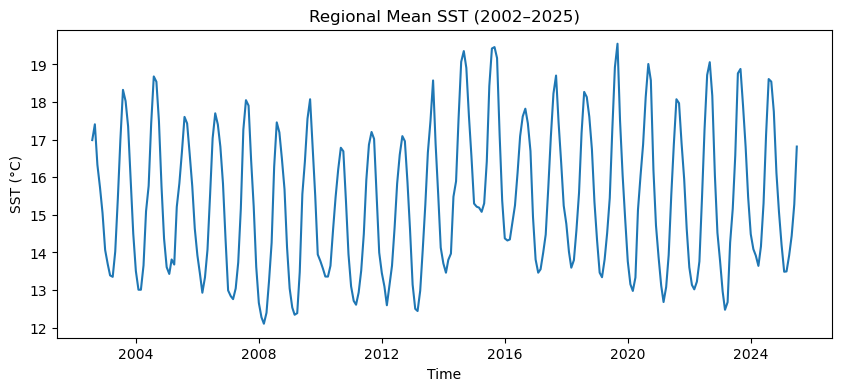

In [26]:
sst_region_subset = sst_region.sel(time=slice("2002-08-01", "2025-07-01"))

sst_region_mean = sst_region_subset.mean(dim=["lat", "lon"])

sst_region_mean.plot(figsize=(10, 4))
plt.title("Regional Mean SST (2002–2025)")
plt.xlabel("Time")
plt.ylabel("SST (°C)")
plt.show()

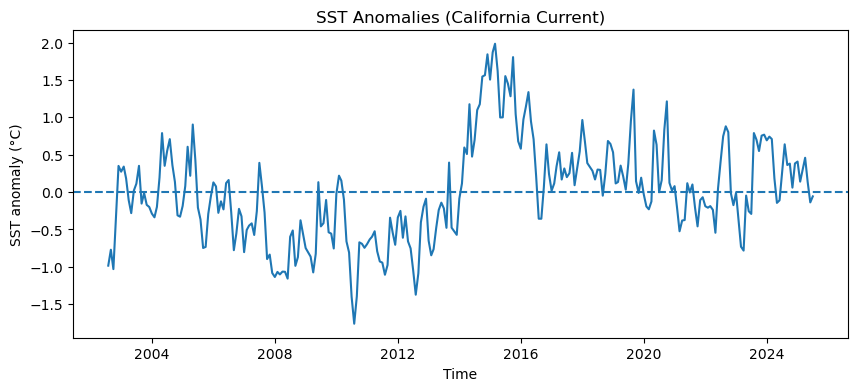

In [48]:
# 计算每个月的气候平均
sst_clim = sst_region_mean.groupby("time.month").mean()

# 计算 anomaly（去掉季节性）
sst_anom = sst_region_mean.groupby("time.month") - sst_clim

sst_anom.plot(figsize=(10,4))
plt.axhline(0, linestyle="--")
plt.title("SST Anomalies (California Current)")
plt.ylabel("SST anomaly (°C)")
plt.show()

## Density Variability of Chlorophyll

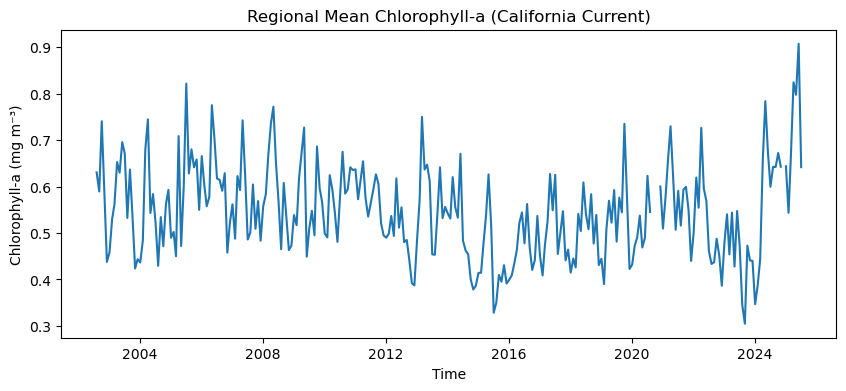

In [29]:
chl_region_mean = chl_region.mean(dim=["lat", "lon"])

chl_region_mean.plot(figsize=(10, 4))
plt.title("Regional Mean Chlorophyll-a (California Current)")
plt.xlabel("Time")
plt.ylabel("Chlorophyll-a (mg m⁻³)")
plt.show()

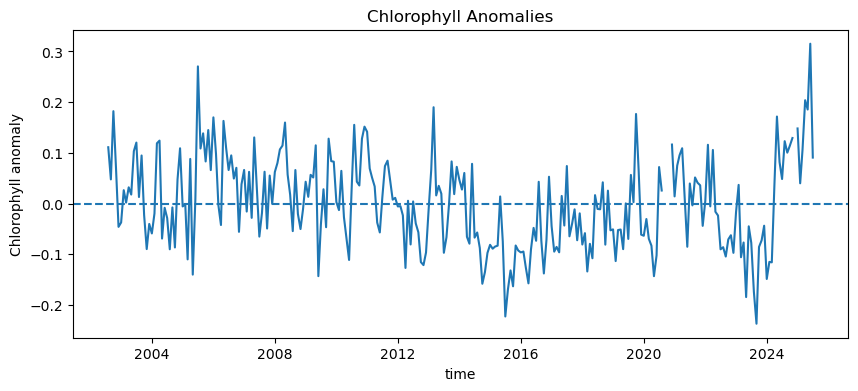

In [49]:
# chlorophyll climatology
chl_clim = chl_region_mean.groupby("time.month").mean()

# chlorophyll anomaly
chl_anom = chl_region_mean.groupby("time.month") - chl_clim

chl_anom.plot(figsize=(10,4))
plt.axhline(0, linestyle="--")
plt.title("Chlorophyll Anomalies")
plt.ylabel("Chlorophyll anomaly")
plt.show()

## SST anomaly vs Chlorophyll anomaly

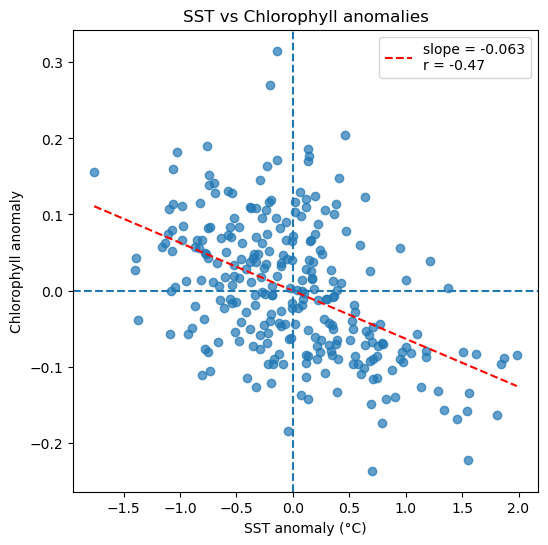

In [50]:
# 对齐时间
common_time = np.intersect1d(sst_anom.time, chl_anom.time)

sst_a = sst_anom.sel(time=common_time)
chl_a = chl_anom.sel(time=common_time)

# 转成 numpy
x = sst_a.values
y = chl_a.values

# 去掉 NaN
mask = np.isfinite(x) & np.isfinite(y)

# 拟合
coef = np.polyfit(x[mask], y[mask], 1)

# 拟合线
xfit = np.linspace(np.nanmin(x), np.nanmax(x), 100)
yfit = np.polyval(coef, xfit)

# 相关系数
r = np.corrcoef(x[mask], y[mask])[0, 1]

plt.figure(figsize=(6,6))

plt.scatter(x, y, alpha=0.7)
plt.plot(xfit, yfit, "r--", label=f"slope = {coef[0]:.3f}\nr = {r:.2f}")

plt.xlabel("SST anomaly (°C)")
plt.ylabel("Chlorophyll anomaly")
plt.title("SST vs Chlorophyll anomalies")

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.legend()
plt.show()

## Relationship between SST and chlorophyll

To examine the direct relationship between ocean temperature and biological productivity, I compared SST anomalies with chlorophyll-a anomalies in the California Current region.

The results show a negative relationship between SST and chlorophyll, with a fitted slope of -0.063 and a correlation coefficient of r = -0.47. This indicates a moderate negative relationship, where warmer conditions are generally associated with lower chlorophyll concentrations.

This pattern is consistent with physical expectations. Higher sea surface temperatures can increase water column stratification, which reduces vertical mixing and limits the supply of nutrients to the surface ocean. As a result, phytoplankton growth may be suppressed during warmer periods, leading to lower chlorophyll concentrations.

## ENSO vs SST anomaly

In [38]:
# 限制 ENSO 时间范围
nino_subset = nino[
    (nino["date"] >= "2002-08-01") &
    (nino["date"] <= "2025-07-01")
]

nino_subset.head()

,date,nino34
655,2002-08-01,0.87
656,2002-09-01,1.09
657,2002-10-01,1.25
658,2002-11-01,1.47
659,2002-12-01,1.37


In [39]:
# 把 ENSO 变成以 date 为 index 的时间序列
nino_ts = nino_subset.set_index("date")

nino_ts.head()

,nino34
date,
2002-08-01,0.87
2002-09-01,1.09
2002-10-01,1.25
2002-11-01,1.47
2002-12-01,1.37


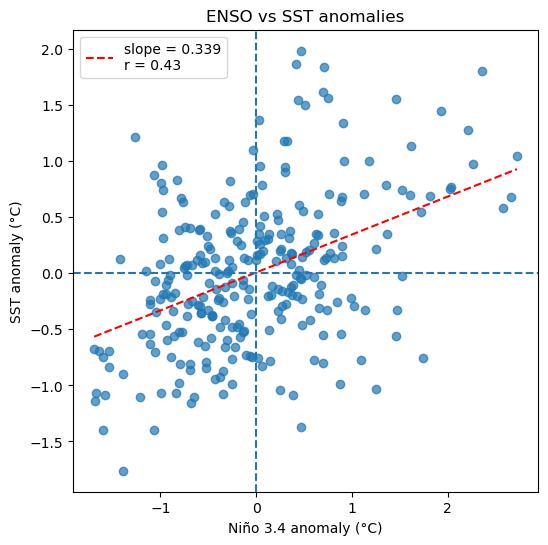

In [51]:
nino_aligned = nino_ts.loc[sst_anom.time.values]

# 转 numpy
x = nino_aligned["nino34"].astype(float).values # 最开始和y写的一样，但是出现错误，np.isfinite() 只接受数值类型（float / int）
y = sst_anom.values

# 去掉 NaN
mask = np.isfinite(x) & np.isfinite(y)

# 拟合
coef = np.polyfit(x[mask], y[mask], 1)

# 拟合线
xfit = np.linspace(np.nanmin(x), np.nanmax(x), 100)
yfit = np.polyval(coef, xfit)

# 相关系数
r = np.corrcoef(x[mask], y[mask])[0, 1]

plt.figure(figsize=(6,6))

plt.scatter(x, y, alpha=0.7)
plt.plot(xfit, yfit, "r--", label=f"slope = {coef[0]:.3f}\nr = {r:.2f}")

plt.xlabel("Niño 3.4 anomaly (°C)")
plt.ylabel("SST anomaly (°C)")
plt.title("ENSO vs SST anomalies")

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.legend()
plt.show()

## ENSO vs chlorophyll

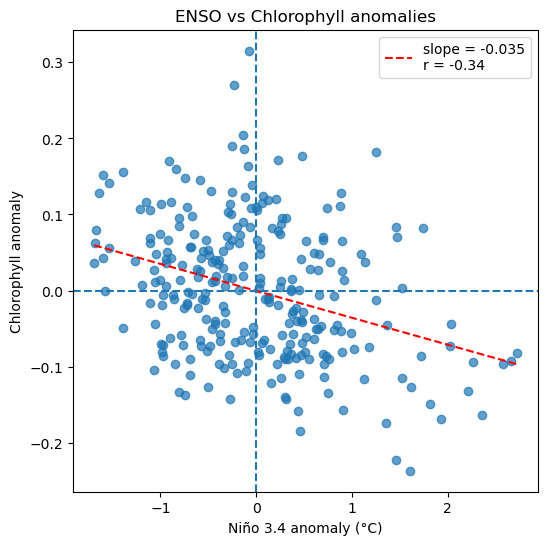

In [52]:
# 对齐时间（用 chlorophyll 的时间）
nino_aligned_chl = nino_ts.loc[chl_anom.time.values]

# 转 numpy
x = nino_aligned_chl["nino34"].astype(float).values
y = chl_anom.values

# 去掉 NaN
mask = np.isfinite(x) & np.isfinite(y)

# 拟合
coef = np.polyfit(x[mask], y[mask], 1)

# 拟合线
xfit = np.linspace(np.nanmin(x), np.nanmax(x), 100)
yfit = np.polyval(coef, xfit)

# 相关系数
r = np.corrcoef(x[mask], y[mask])[0, 1]

plt.figure(figsize=(6,6))

plt.scatter(x, y, alpha=0.7)
plt.plot(xfit, yfit, "r--", label=f"slope = {coef[0]:.3f}\nr = {r:.2f}")

plt.xlabel("Niño 3.4 anomaly (°C)")
plt.ylabel("Chlorophyll anomaly")
plt.title("ENSO vs Chlorophyll anomalies")

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.legend()
plt.show()

## Role of ENSO in SST and chlorophyll variability

To better understand the drivers of variability in the California Current, I examined the relationship between ENSO (Niño 3.4 index), SST anomalies, and chlorophyll anomalies.

The results show that ENSO has a moderate positive relationship with SST (slope = 0.339, r = 0.43), indicating that El Niño conditions are generally associated with warmer sea surface temperatures in this region. In contrast, ENSO shows a negative relationship with chlorophyll (slope = -0.035, r = -0.34), suggesting that warmer ENSO phases tend to correspond to reduced phytoplankton biomass.

Combining these results with the negative relationship between SST and chlorophyll (slope = -0.063, r = -0.47), the analysis suggests a consistent mechanism: ENSO-driven warming may suppress ocean productivity, likely through increased stratification and reduced nutrient supply in the surface ocean.